In [29]:
from comet_ml import start
from comet_ml.integration.pytorch import log_model

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset

import joblib
from models.clusterizer import Clusterizer
from data.generate_latent_spaces import _load_model
from typing import Optional
from utils import load_config

experiment = start(
    api_key="QWOxSIxgY5YQBTvC476IEIxSG", # nie wiem czy tego nie wywalic do osobnego pliku
    project_name="diffusion",
    workspace="ekipa"
)

COMET INFO: An experiment with the same configuration options is already running and will be reused.


In [30]:
clusterizer = joblib.load('./data/models/clusterizer.pkl')
training_latent_space = np.load('./data/latent_spaces/train.npz')
testing_latent_space = np.load('./data/latent_spaces/test.npz')

In [32]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

from models.autoencoder import get_autoencoder

config = load_config('./../config.yaml')

model = get_autoencoder(config["model"]["architecture"])()
# summary(model)
autoencoder = _load_model('./checkpoints/autoencoder-8k-extra-convolutions-at-the-end-final.ckpt', config, device)

In [33]:
training_full_images = torch.tensor(training_latent_space['full']).to(device)
training_cut_images = torch.tensor(training_latent_space['cut']).to(device)
test_full_images = torch.tensor(testing_latent_space['full']).to(device)
test_cut_images = torch.tensor(testing_latent_space['cut']).to(device)

training_cut_classes = torch.tensor(clusterizer.predict(training_latent_space['cut'].reshape(len(training_latent_space['cut']), -1))).to(device)
testing_cut_classes = torch.tensor(clusterizer.predict(testing_latent_space['cut'].reshape(len(testing_latent_space['cut']), -1))).to(device)

In [35]:

# TODO - ATENCJA, oddzielny kanal dla maski
# moze klasa UNet by sie przydala
class UNet(nn.Module): # chuj nie UNet to jest
    def __init__(self, up_network: list[nn.Module], down_network: list[nn.Module]): # sam network - celujemy w jakie 20 mlnow parametrow - proponuje same male convy2d
        super().__init__()
        self.down = nn.ModuleList( down_network )
        self.up   = nn.ModuleList( up_network )

    def forward(self, x):
        skips = []
        out = x
        for down in self.down:
            out = down(out)
            skips.append(out)

        for up in self.up:
            out = torch.cat([out, skips.pop()], dim=1)
            out = up(out)

        return out

In [ ]:
class Diffusion(nn.Module):
    def __init__(
            self, 
            network: nn.Module, 
            lr: float = 1e-6, # z artkulu 
            loss_function: nn.Module = nn.MSELoss(), # skalowlnego KLa (to chyba do wariacyjnego encodera) 
            cut_train: Optional[torch.Tensor] = None,
            orig_train: Optional[torch.Tensor] = None,
            cut_training_classes: Optional[torch.Tensor] = None,
            cut_test_classes: Optional[torch.Tensor] = None, 
            cut_test: Optional[torch.Tensor] = None,
            orig_test: Optional[torch.Tensor] = None
        ):
        super().__init__()
        self.network = network
        self.optim = torch.optim.Adam(self.parameters(), lr)
        self.loss = loss_function

        self.train_loss_record = None
        self.test_loss_record = None

        self.training_dataset = None
        self.test_dataset = None

        # na dataseta to
        if cut_train is not None and orig_train is not None and cut_training_classes is not None:
            self.load_data(cut_train, orig_train, cut_training_classes, cut_test_classes, cut_test, orig_test)

    def training_step(self, input: torch.Tensor, target: torch.Tensor, class_to_go: torch.Tensor):
        noise = torch.randn_like(input) # chyba za duzo
        input += noise

    def forward(self, input):
        return self.network(input)
    
    def load_model(self, path): #TODO
        pass

    def load_data(
            self, 
            cut_train: torch.Tensor, 
            orig_train: torch.Tensor, 
            cut_training_classes: torch.Tensor,
            cut_test_classes: Optional[torch.Tensor] = None, 
            cut_test: Optional[torch.Tensor] = None, 
            orig_test: Optional[torch.Tensor] = None,
        ):
        tensor_training = TensorDataset(cut_train, orig_train, cut_training_classes)
        self.training_dataset = DataLoader(
            tensor_training,
            batch_size=16,
            shuffle=True,
            num_workers=3
        )

        if cut_test is not None and orig_test is not None: # zakladamy ze user nie jest kretynem (w moim przypadku to sie ie palikuje)
            tensor_testing = TensorDataset(cut_test, orig_test, cut_test_classes)
            self.test_dataset = DataLoader(
                tensor_testing,
                batch_size = 16,
                num_workers = 3
            )

In [ ]:
in_net = [ # plaski UNet
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(), # podobno groupnorm jest ciekawa opcja
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
]

out_net = [ # plaski UNet
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1), nn.SiLU(),
]

unecik = UNet(in_net, out_net)

diffusion = Diffusion(
    unecik,
    1e-5,
    cut_train=training_cut_images,
    orig_train=training_full_images,
    cut_training_classes=training_cut_classes,
    cut_test_classes=testing_cut_classes,
    cut_test=test_cut_images,
    orig_test=test_full_images
)

for epoch in range(100):
    for x_train, y_train, classes in diffusion.training_dataset.dataset:
        diffusion.training_step()

#TODO wizualizacja

cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0
cuda:0

KeyboardInterrupt: 

UNet budowany generalnie z convow 2D autorzy mowia

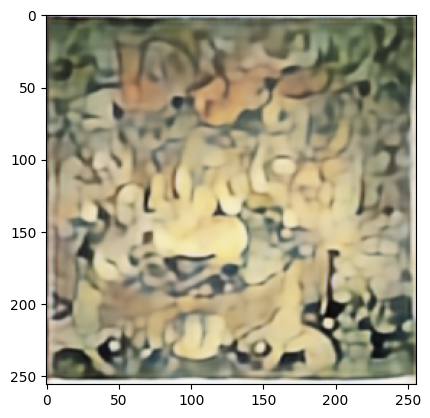

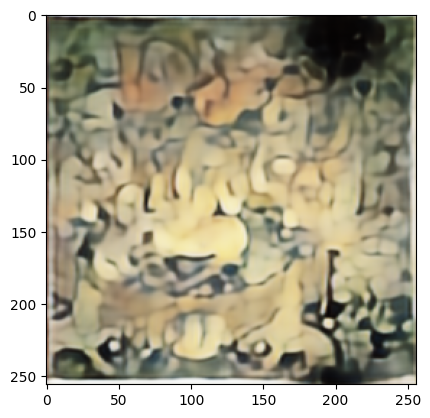

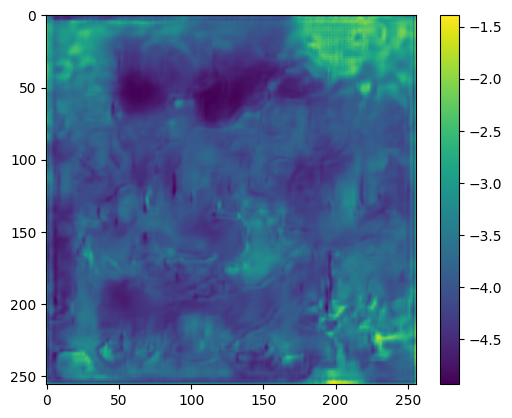

In [57]:
dummy_full = torch.Tensor(full_images[0:1]).cuda()
dummy_training = torch.Tensor(cut_images[0:1]).cuda()

cos = model.decoder(dummy_full)
ret1 = cos[0][1:,:,:].permute(1, 2, 0).cpu().detach().numpy()

cos = model.decoder(dummy_training)
ret2 = cos[0][1:,:,:].permute(1, 2, 0).cpu().detach().numpy()

plt.imshow(ret1)
plt.show()
plt.imshow(ret2)
plt.show()
plt.imshow(cos[0][:1,:,:].permute(1,2,0).cpu().detach().numpy() + 1e-5 ))
plt.colorbar()